In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

file_path = "dataset.csv"

df = pd.read_csv(file_path, nrows=20000, low_memory=False)

print("Loaded rows:", len(df))
print("\nShape:", df.shape)
print("\nTop Columns:")
print(df.columns[:10])

Loaded rows: 20000

Shape: (20000, 151)

Top Columns:
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade'],
      dtype='object')



Top Missing Columns:
revol_bal_joint             100.0
member_id                   100.0
sec_app_fico_range_low      100.0
sec_app_fico_range_high     100.0
sec_app_earliest_cr_line    100.0
sec_app_inq_last_6mths      100.0
sec_app_mort_acc            100.0
sec_app_open_acc            100.0
sec_app_revol_util          100.0
sec_app_open_act_il         100.0
dtype: float64


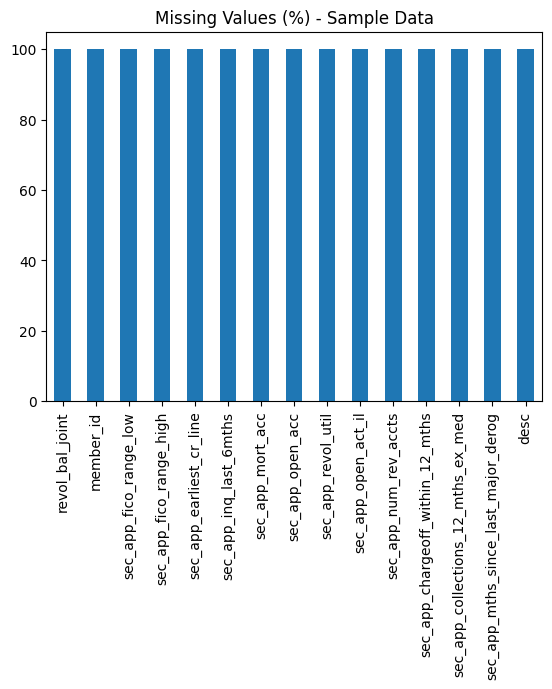


Loan Status Distribution:
loan_status
Fully Paid            14154
Charged Off            3571
Current                2120
Late (31-120 days)      106
In Grace Period          41
Late (16-30 days)         8
Name: count, dtype: int64


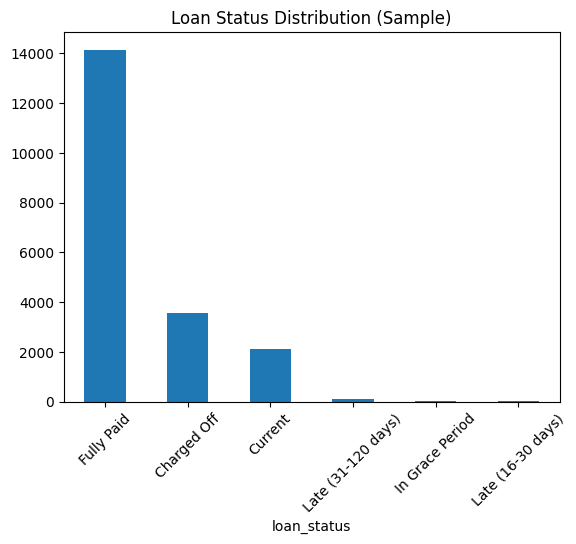

In [3]:
# STEP - Dealing with missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\nTop Missing Columns:")
print(missing_percent.head(10))

plt.figure()
missing_percent.head(15).plot(kind='bar')
plt.title("Missing Values (%) - Sample Data")
plt.xticks(rotation=90)
plt.show()

print("\nLoan Status Distribution:")
print(df['loan_status'].value_counts())

df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution (Sample)")
plt.xticks(rotation=45)
plt.show()

In [4]:
# STEP - SELECTIVE CLEANING

print("\nOriginal Loan Status:\n", df['loan_status'].value_counts())

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df = df.copy() 

df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

# Dropping columns with 100% missing data
missing_percent = df.isnull().mean() * 100
full_missing_cols = missing_percent[missing_percent == 100].index
print("\n100% Missing Columns:\n", list(full_missing_cols))

df.drop(columns=full_missing_cols, inplace=True)

print("\nShape after removing 100% missing columns:", df.shape)

# Creating missing flags
missing_percent = df.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 30].index

for col in high_missing_cols:
    df[col + "_missing_flag"] = df[col].isnull().astype(int)

# Imputation

# Numeric columns
num_cols = df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())  

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  
missing_after = df.isnull().mean() * 100


Original Loan Status:
 loan_status
Fully Paid            14154
Charged Off            3571
Current                2120
Late (31-120 days)      106
In Grace Period          41
Late (16-30 days)         8
Name: count, dtype: int64

100% Missing Columns:
 ['member_id', 'next_pymnt_d', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']

Shape after removing 100% missing columns: (17725, 137)



Before Conversion:

         term emp_length  int_rate
0   36 months  10+ years     13.99
1   36 months  10+ years     11.99
2   60 months  10+ years     10.78
4   60 months    3 years     22.45
5   36 months    4 years     13.44

After Conversion:

   term  emp_length  int_rate
0  36.0        10.0     13.99
1  36.0        10.0     11.99
2  60.0        10.0     10.78
4  60.0         3.0     22.45
5  36.0         4.0     13.44


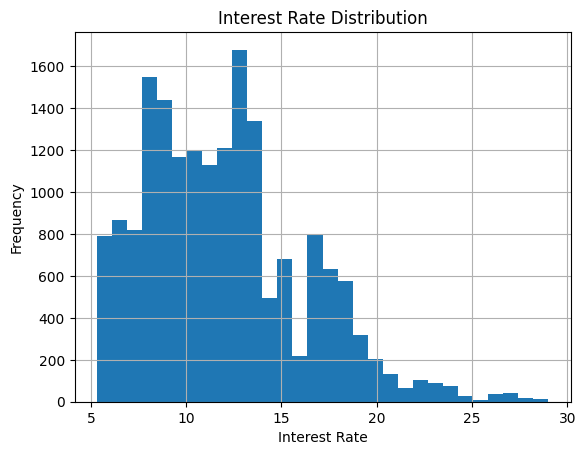


Data Types Summary:

float64    102
object      32
int32       30
int64        2
Name: count, dtype: int64


In [5]:
# STEP - Data Type Cleaning + Feature Engineering 

print("\nBefore Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())

# Term
if df['term'].dtype == 'object':
    df['term'] = df['term'].str.extract(r'(\d+)').astype(float) 

# Employment Length
if df['emp_length'].dtype == 'object':
    df['emp_length'] = df['emp_length'].str.replace(r'\D', '', regex=True)
    df['emp_length'] = df['emp_length'].replace('', 0)
    df['emp_length'] = df['emp_length'].astype(float)

# Interest Rate
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
else:
    df['int_rate'] = df['int_rate'].astype(float)

# Revol Util
if 'revol_util' in df.columns:
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)
    else:
        df['revol_util'] = df['revol_util'].astype(float)

# Date processing 
date_cols = ['issue_d']
new_cols = {}

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        new_cols[col + '_year'] = df[col].dt.year

# Add all new columns at once
df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)

# Drop original date
df.drop(columns=date_cols, inplace=True, errors='ignore')

# After Check
print("\nAfter Conversion:\n")
print(df[['term', 'emp_length', 'int_rate']].head())

# Graph
plt.figure()
df['int_rate'].hist(bins=30)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

print("\nData Types Summary:\n")
print(df.dtypes.value_counts())

In [10]:
# STEP 4: Outlier Handling

import matplotlib.pyplot as plt
cols_to_treat = ['loan_amnt', 'annual_inc', 'int_rate']
def cap_outliers(column):
    lower = column.quantile(0.05)
    upper = column.quantile(0.95)
    
    print(f"\n{column.name}:")
    print("Lower cap:", lower)
    print("Upper cap:", upper)
    
    return column.clip(lower, upper)
for col in cols_to_treat:
    if col in df.columns:
        df[col] = cap_outliers(df[col])


loan_amnt:
Lower cap: 3000.0
Upper cap: 32000.0

annual_inc:
Lower cap: 28000.0
Upper cap: 160000.0

int_rate:
Lower cap: 6.24
Upper cap: 19.48


In [6]:
# STEP - Encoding 
cat_cols = df.select_dtypes(include=['object', 'category']).columns
low_card_cols = []
high_card_cols = []

for col in cat_cols:
    if df[col].nunique() < 15:
        low_card_cols.append(col)
    else:
        high_card_cols.append(col)
# ONE-HOT ENCODING
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

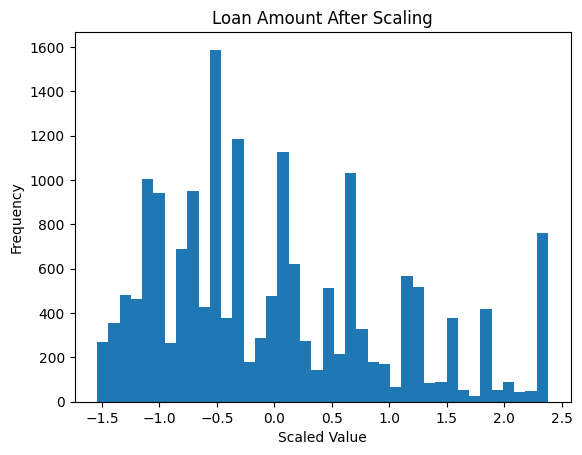

In [7]:
# STEP- FEATURE SCALING

from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Separate features & target
X = df.drop('target', axis=1)
y = df['target']

# Only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Graph
plt.figure()
plt.hist(X['loan_amnt'], bins=40)
plt.title("Loan Amount After Scaling")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

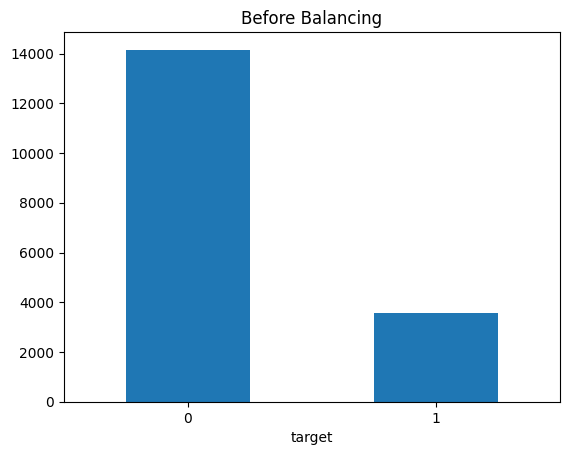


Class Distribution After:

target
0.0    12609
1.0    12609
Name: count, dtype: int64


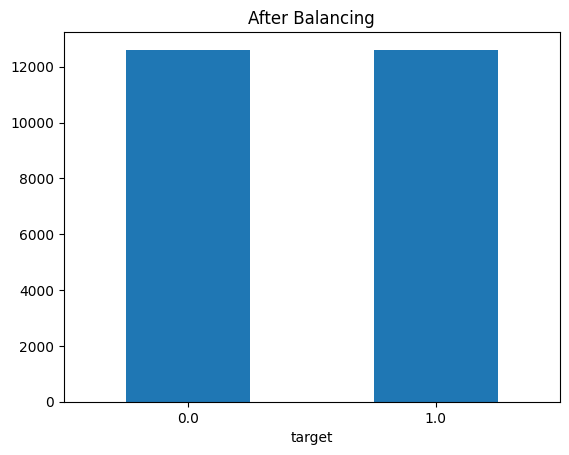

In [14]:
# STEP - HANDLE CLASS IMBALANCE

import matplotlib.pyplot as plt
from sklearn.utils import resample

y.value_counts().plot(kind='bar')
plt.title("Before Balancing")
plt.xticks(rotation=0)
plt.show()

df_bal = X.copy()
df_bal['target'] = y

majority = df_bal[df_bal['target'] == 0]
minority = df_bal[df_bal['target'] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)
X = df_balanced.drop('target', axis=1)
y = df_balanced['target']

print("\nClass Distribution After:\n")
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title("After Balancing")
plt.xticks(rotation=0)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [31]:
print(X.shape)
import pandas as pd

X = pd.DataFrame(X)

(1254, 103)


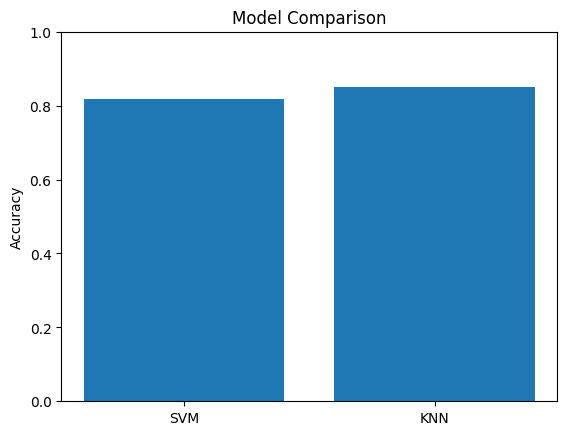

SVM Accuracy: 0.8166666666666667
KNN Accuracy: 0.85


In [32]:
# ---- FIX 1: Fill NaNs FIRST ----
X = X.fillna(0)

# ---- FIX 2: Combine X and y safely ----
df_temp = X.copy()
df_temp['target'] = y

# ---- FIX 3: Remove NaN from target ----
df_temp = df_temp.dropna(subset=['target'])

# ---- FIX 4: Safe sampling ----
sample_size = min(5000, len(df_temp))
df_temp = df_temp.sample(sample_size, random_state=42)

# Split back
X = df_temp.drop('target', axis=1)
y = df_temp['target']

# ---- FIX 5: Scaling ----
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---- Train-test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------- SVM --------
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# -------- KNN --------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# -------- GRAPH --------
models = ['SVM', 'KNN']
scores = [svm_acc, knn_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ---- Results ----
print("SVM Accuracy:", svm_acc)
print("KNN Accuracy:", knn_acc)


import warnings
warnings.filterwarnings('ignore')

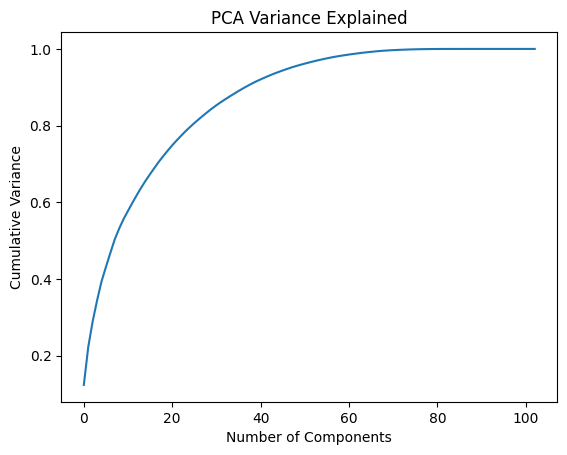


Original Features: 103
Reduced Features: 48

SVM Accuracy After PCA: 0.65


In [33]:
# STEP 9: PCA

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Variance Explained")
plt.show()


# Applying PCA (95% variance)
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)
print("\nOriginal Features:", X.shape[1])
print("Reduced Features:", X_pca.shape[1])


# -------- 3. TRAIN TEST SPLIT --------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -------- 4. TRAIN SVM AGAIN --------
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='rbf', class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\nSVM Accuracy After PCA:", accuracy_score(y_test, y_pred))